# 27 - HAR × sentiment composition operator

**Question.** When the independent HAR volatility target is already below
full exposure, should the unchanged sentiment risk-off value of 25% multiply
HAR exposure, or act as an absolute maximum exposure?

Notebook 24 used the product, which can reduce exposure to 6.25%. That may
double-count risk because both HAR and sentiment are downside controls. This
notebook tests one alternative only:

- **HAR base:** unchanged sentiment-free 10% volatility target.
- **Product:** `HAR × sentiment`, exactly reproducing Notebooks 24/25.
- **Absolute cap:** `min(HAR, sentiment)`. Since HAR is bounded below at 25%,
  this means exactly 25% exposure during the unchanged 1.5/0.5 risk-off state.

The operator is applied unchanged to both 2013–2019 and 2020–2023, at 2 bps
per side with entry, transition, and liquidation costs. There is no threshold,
cost, lookback, or exposure sweep. Both eras are already opened; this is an
iterative operator-selection audit, not a new holdout.

**Frozen gates.** The cap is preferred to the product only if it has
nonnegative paired mean-return and Sharpe differences in both eras, is no more
than 10% relatively worse in maximum drawdown than the product in either era,
and still reduces downside-squared loss versus HAR in both eras. Alpha and
useful-risk promotion retain the stricter existing return, Sharpe, drawdown,
downside, and cross-era requirements.

In [1]:
from __future__ import annotations

import json
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "final_experiments":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from final_experiments.lib.aggregators import benjamini_hochberg  # noqa: E402
from final_experiments.lib.plots import CATEGORICAL, INK, apply_house_style  # noqa: E402
from final_experiments.lib.risk_overlay import (  # noqa: E402
    MomentumOverlayConfig,
    summarize_weight_backtest,
)
from final_experiments.lib.volatility_target import (  # noqa: E402
    backtest_single_asset_exposure,
    compose_sentiment_risk_exposure,
    paired_circular_block_mean,
)

SEED = 20260805
COST_BPS = 2.0
COST_GRID = (0.0, 1.0, 2.0, 5.0, 10.0)
BLOCK_LENGTH = 20
REPLICATIONS = 4_999
ARMS = ("har_base", "product", "absolute_cap")

OUTPUT_DIR = REPO_ROOT / "final_experiments/outputs/27_fnspid_har_sentiment_composition"
INPUTS = {
    "pre_2020": {
        "base": REPO_ROOT
        / "final_experiments/outputs/25_fnspid_har_sentiment_walkforward/walkforward_har_daily.parquet",
        "product": REPO_ROOT
        / "final_experiments/outputs/25_fnspid_har_sentiment_walkforward/walkforward_har_sentiment_daily.parquet",
    },
    "evaluation": {
        "base": REPO_ROOT
        / "final_experiments/outputs/24_fnspid_har_sentiment_hysteresis/evaluation_control_har_target_daily.parquet",
        "product": REPO_ROOT
        / "final_experiments/outputs/24_fnspid_har_sentiment_hysteresis/evaluation_har_sentiment_daily.parquet",
    },
}
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
apply_house_style()
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

## Reconstruct and audit the unchanged sentiment state

The saved product and base exposure paths determine the sentiment modifier
exactly: their ratio must be either 1.00 or 0.25. Rebuilding both saved paths
through the shared helper guards against an accounting or alignment change.

In [2]:
saved: dict[str, dict[str, pd.DataFrame]] = {}
returns: dict[str, pd.DataFrame] = {}
exposures: dict[str, dict[str, pd.DataFrame]] = {}
daily_paths: dict[str, dict[str, pd.DataFrame]] = {}
audit_rows: list[dict[str, float | int | str | bool]] = []

for era, paths in INPUTS.items():
    base_saved = pd.read_parquet(paths["base"]).sort_values("session_date").reset_index(drop=True)
    product_saved = pd.read_parquet(paths["product"]).sort_values("session_date").reset_index(drop=True)
    for frame in (base_saved, product_saved):
        frame["session_date"] = pd.to_datetime(frame["session_date"]).dt.normalize()
    merged = base_saved[["session_date", "exposure"]].merge(
        product_saved[["session_date", "exposure"]],
        on="session_date",
        how="inner",
        validate="1:1",
        suffixes=("_base", "_product"),
    )
    if len(merged) != len(base_saved) or len(merged) != len(product_saved):
        raise ValueError(f"{era}: base/product sessions do not match")
    ratio = merged["exposure_product"] / merged["exposure_base"]
    nearest = np.where(np.isclose(ratio, 0.25, atol=1e-12), 0.25, 1.0)
    if not np.allclose(ratio, nearest, atol=1e-12):
        raise ValueError(f"{era}: saved product does not imply only 1.00/0.25 sentiment states")

    base_exposure = merged[["session_date", "exposure_base"]].rename(
        columns={"exposure_base": "exposure"}
    )
    modifier = pd.DataFrame({"session_date": merged["session_date"], "exposure": nearest})
    product_exposure = compose_sentiment_risk_exposure(
        base_exposure,
        modifier,
        mode="multiplier",
        arm="product",
    )
    cap_exposure = compose_sentiment_risk_exposure(
        base_exposure,
        modifier,
        mode="absolute_cap",
        arm="absolute_cap",
    )
    return_frame = base_saved[["session_date", "forward_return"]].copy()
    era_exposures = {
        "har_base": base_exposure.assign(arm="har_base"),
        "product": product_exposure,
        "absolute_cap": cap_exposure,
    }
    era_daily = {
        arm: backtest_single_asset_exposure(
            return_frame,
            exposure,
            cost_bps_per_side=COST_BPS,
        ).assign(downside_sq=lambda d: np.minimum(d["net_return"], 0.0) ** 2)
        for arm, exposure in era_exposures.items()
    }

    product_exposure_exact = bool(
        np.allclose(
            product_exposure["exposure"],
            product_saved["exposure"],
            atol=1e-12,
        )
    )
    base_return_exact = bool(
        np.allclose(era_daily["har_base"]["net_return"], base_saved["net_return"], atol=1e-12)
    )
    product_return_exact = bool(
        np.allclose(era_daily["product"]["net_return"], product_saved["net_return"], atol=1e-12)
    )
    if not (product_exposure_exact and base_return_exact and product_return_exact):
        raise RuntimeError(f"{era}: failed to reproduce an upstream saved path")

    risk_off = modifier["exposure"].eq(0.25)
    audit_rows.append(
        {
            "era": era,
            "sessions": len(merged),
            "first_session": merged["session_date"].min(),
            "last_session": merged["session_date"].max(),
            "risk_off_sessions": int(risk_off.sum()),
            "risk_off_share": float(risk_off.mean()),
            "product_min_exposure": float(product_exposure["exposure"].min()),
            "cap_min_exposure": float(cap_exposure["exposure"].min()),
            "product_exposure_exact": product_exposure_exact,
            "base_return_exact": base_return_exact,
            "product_return_exact": product_return_exact,
        }
    )
    saved[era] = {"base": base_saved, "product": product_saved}
    returns[era] = return_frame
    exposures[era] = era_exposures
    daily_paths[era] = era_daily

input_audit = pd.DataFrame(audit_rows)
display(input_audit)

,era,sessions,first_session,last_session,risk_off_sessions,risk_off_share,product_min_exposure,cap_min_exposure,product_exposure_exact,base_return_exact,product_return_exact
0,pre_2020,1759,2013-01-04,2019-12-30,194,0.110290,0.088720,0.250000,True,True,True
1,evaluation,998,2020-01-02,2023-12-18,125,0.125251,0.062500,0.250000,True,True,True


## Full-era results

Gross and net Sharpes are both shown. Each summary uses identical returns and
exposure costs; only the composition operator changes.

In [3]:
summary_config = MomentumOverlayConfig(
    cost_bps_per_side=COST_BPS,
    bootstrap_block_length=BLOCK_LENGTH,
    bootstrap_replications=REPLICATIONS,
    random_seed=SEED,
)
result_rows: list[dict[str, float | int | str]] = []
for era, arms in daily_paths.items():
    for arm, daily in arms.items():
        result_rows.append({"era": era, "arm": arm, **summarize_weight_backtest(daily, config=summary_config)})
results = pd.DataFrame(result_rows)
display(
    results[
        [
            "era",
            "arm",
            "n_sessions",
            "sharpe_gross",
            "sharpe_net",
            "total_return_net",
            "ann_vol_net",
            "max_drawdown",
            "mean_turnover",
            "mean_gross_exposure",
        ]
    ]
)

,era,arm,n_sessions,sharpe_gross,sharpe_net,total_return_net,ann_vol_net,max_drawdown,mean_turnover,mean_gross_exposure
0,pre_2020,har_base,1759,1.136350,1.113905,0.969064,0.090871,-0.125291,0.020182,0.815479
1,pre_2020,product,1759,1.215290,1.163947,0.931349,0.084070,-0.085706,0.042708,0.756500
2,pre_2020,absolute_cap,1759,1.222781,1.176133,0.954941,0.084725,-0.089993,0.039083,0.764413
3,evaluation,har_base,998,0.693755,0.672674,0.298474,0.106498,-0.157300,0.022285,0.618573
4,evaluation,product,998,0.878027,0.835075,0.352038,0.096831,-0.163625,0.041261,0.569306
5,evaluation,absolute_cap,998,0.804608,0.769209,0.331751,0.100651,-0.156694,0.035357,0.584196


## Paired inference and declared multiplicity

The family contains two eras × two comparators for each of two outcomes.
Return is `cap − comparator`; downside is `comparator − cap`, so positive
values favour the cap in both tables. BH is applied separately to the four
return tests and the four downside tests.

In [4]:
inference_rows: list[dict[str, float | int | str | bool]] = []
for era_offset, era in enumerate(INPUTS):
    cap = daily_paths[era]["absolute_cap"].set_index("session_date")
    for comparator_offset, comparator in enumerate(("har_base", "product")):
        other = daily_paths[era][comparator].set_index("session_date")
        common = cap.index.intersection(other.index).sort_values()
        values = {
            "net_return": cap.loc[common, "net_return"] - other.loc[common, "net_return"],
            "downside_sq": other.loc[common, "downside_sq"] - cap.loc[common, "downside_sq"],
        }
        for outcome_offset, (outcome, difference) in enumerate(values.items()):
            estimate = paired_circular_block_mean(
                difference,
                block_length=BLOCK_LENGTH,
                replications=REPLICATIONS,
                seed=SEED + era_offset * 20 + comparator_offset * 4 + outcome_offset,
            )
            inference_rows.append(
                {
                    "era": era,
                    "comparator": comparator,
                    "outcome": outcome,
                    "positive_favours_cap": True,
                    **estimate,
                }
            )
inference = pd.DataFrame(inference_rows)
inference["bh_reject_q05"] = False
for _outcome, index in inference.groupby("outcome").groups.items():
    inference.loc[index, "bh_reject_q05"] = benjamini_hochberg(
        inference.loc[index, "p_two_sided"].tolist(),
        q=0.05,
    )
display(inference)

,era,comparator,outcome,positive_favours_cap,n,mean,ci_low,ci_high,p_two_sided,block_length,replications,seed,bh_reject_q05
0,pre_2020,har_base,net_return,True,1759,-0.000006,-0.000082,0.000073,0.875600,20,4999,20260805,False
1,pre_2020,har_base,downside_sq,True,1759,0.000003,0.000001,0.000004,0.006400,20,4999,20260806,True
2,pre_2020,product,net_return,True,1759,0.000007,-0.000007,0.000021,0.311000,20,4999,20260809,False
3,pre_2020,product,downside_sq,True,1759,-0.000000,-0.000000,-0.000000,0.012800,20,4999,20260810,True
4,evaluation,har_base,net_return,True,998,0.000023,-0.000063,0.000113,0.605800,20,4999,20260825,False
5,evaluation,har_base,downside_sq,True,998,0.000003,0.000001,0.000005,0.003000,20,4999,20260826,True
6,evaluation,product,net_return,True,998,-0.000014,-0.000096,0.000048,0.725200,20,4999,20260829,False
7,evaluation,product,downside_sq,True,998,-0.000002,-0.000005,-0.000000,0.084400,20,4999,20260830,False


## Costs, exposure mechanics, and temporal stability

The cost grid is diagnostic only; the decision remains at 2 bps. Subperiods
are the same ones already used by Notebooks 24 and 25.

In [5]:
cost_rows: list[dict[str, float | int | str]] = []
for era in INPUTS:
    for arm, exposure in exposures[era].items():
        for cost in COST_GRID:
            daily = backtest_single_asset_exposure(
                returns[era],
                exposure,
                cost_bps_per_side=cost,
            )
            config = MomentumOverlayConfig(
                cost_bps_per_side=cost,
                bootstrap_block_length=BLOCK_LENGTH,
                bootstrap_replications=999,
                random_seed=SEED,
            )
            cost_rows.append(
                {
                    "era": era,
                    "arm": arm,
                    "cost_bps_per_side": cost,
                    **summarize_weight_backtest(daily, config=config),
                }
            )
cost_curve = pd.DataFrame(cost_rows)

subperiods = (
    ("pre_2020", "2013_2015", "2013-01-01", "2015-12-31"),
    ("pre_2020", "2016_2019", "2016-01-01", "2019-12-31"),
    ("evaluation", "2020", "2020-01-01", "2020-12-31"),
    ("evaluation", "2021_2023", "2021-01-01", "2023-12-31"),
)
temporal_rows: list[dict[str, float | int | str]] = []
for era, period, start, end in subperiods:
    for arm, daily in daily_paths[era].items():
        subset = daily.loc[daily["session_date"].between(pd.Timestamp(start), pd.Timestamp(end))]
        temporal_rows.append(
            {
                "era": era,
                "period": period,
                "arm": arm,
                **summarize_weight_backtest(subset, config=summary_config),
            }
        )
temporal = pd.DataFrame(temporal_rows)

exposure_rows: list[dict[str, float | int | str]] = []
for era, era_exposures in exposures.items():
    modifier = era_exposures["product"][["session_date", "modifier_exposure"]]
    risk_off_dates = set(modifier.loc[modifier["modifier_exposure"].eq(0.25), "session_date"])
    for arm, exposure in era_exposures.items():
        use = exposure.loc[exposure["session_date"].isin(risk_off_dates)]
        exposure_rows.append(
            {
                "era": era,
                "arm": arm,
                "risk_off_sessions": len(use),
                "risk_off_mean_exposure": float(use["exposure"].mean()),
                "risk_off_min_exposure": float(use["exposure"].min()),
                "full_mean_exposure": float(exposure["exposure"].mean()),
            }
        )
exposure_summary = pd.DataFrame(exposure_rows)
display(cost_curve[["era", "arm", "cost_bps_per_side", "sharpe_net", "total_return_net"]])
display(temporal[["period", "arm", "sharpe_net", "total_return_net", "max_drawdown"]])
display(exposure_summary)

,era,arm,cost_bps_per_side,sharpe_net,total_return_net
0,pre_2020,har_base,0.000000,1.136350,0.997220
1,pre_2020,har_base,1.000000,1.125128,0.983092
2,pre_2020,har_base,2.000000,1.113905,0.969064
3,pre_2020,har_base,5.000000,1.080233,0.927572
4,pre_2020,har_base,10.000000,1.024103,0.860350
5,pre_2020,product,0.000000,1.215290,0.990254
6,pre_2020,product,1.000000,1.189623,0.960580
7,pre_2020,product,2.000000,1.163947,0.931349
8,pre_2020,product,5.000000,1.086876,0.846236
9,pre_2020,product,10.000000,0.958324,0.712613


,period,arm,sharpe_net,total_return_net,max_drawdown
0,2013_2015,har_base,1.002573,0.316726,-0.095223
1,2013_2015,product,1.069905,0.321990,-0.085706
2,2013_2015,absolute_cap,1.077698,0.325867,-0.087376
3,2016_2019,har_base,1.209212,0.495425,-0.125291
4,2016_2019,product,1.251284,0.460941,-0.080253
5,2016_2019,absolute_cap,1.265759,0.474463,-0.087256
6,2020,har_base,0.597468,0.066817,-0.129468
7,2020,product,1.355239,0.145196,-0.073924
8,2020,absolute_cap,0.856576,0.096530,-0.115779
9,2021_2023,har_base,0.704857,0.217148,-0.157300


,era,arm,risk_off_sessions,risk_off_mean_exposure,risk_off_min_exposure,full_mean_exposure
0,pre_2020,har_base,194,0.713013,0.354880,0.815479
1,pre_2020,product,194,0.178253,0.088720,0.756500
2,pre_2020,absolute_cap,194,0.250000,0.250000,0.764413
3,evaluation,har_base,125,0.524466,0.250000,0.618573
4,evaluation,product,125,0.131116,0.062500,0.569306
5,evaluation,absolute_cap,125,0.250000,0.250000,0.584196


## Frozen gates

The operator-selection gate asks whether the cap is a better implementation
of the same sentiment state than the product. Promotion remains a much higher
bar against HAR itself.

In [6]:
result_index = results.set_index(["era", "arm"])
inference_index = inference.set_index(["era", "comparator", "outcome"])
operator_checks: list[dict[str, float | str | bool]] = []
for era in INPUTS:
    product = result_index.loc[(era, "product")]
    cap = result_index.loc[(era, "absolute_cap")]
    base = result_index.loc[(era, "har_base")]
    product_return = inference_index.loc[(era, "product", "net_return")]
    base_downside = inference_index.loc[(era, "har_base", "downside_sq")]
    drawdown_relative_vs_product = float(
        1.0 - abs(cap["max_drawdown"]) / abs(product["max_drawdown"])
    )
    operator_checks.append(
        {
            "era": era,
            "cap_minus_product_bps_day": float(product_return["mean"] * 10_000),
            "cap_minus_product_sharpe": float(cap["sharpe_net"] - product["sharpe_net"]),
            "drawdown_relative_vs_product": drawdown_relative_vs_product,
            "cap_minus_base_sharpe": float(cap["sharpe_net"] - base["sharpe_net"]),
            "base_minus_cap_downside_sq": float(base_downside["mean"]),
            "cap_beats_product_mean": bool(product_return["mean"] >= 0),
            "cap_beats_product_sharpe": bool(cap["sharpe_net"] >= product["sharpe_net"]),
            "cap_drawdown_within_10pct_of_product": bool(drawdown_relative_vs_product >= -0.10),
            "cap_reduces_downside_vs_base": bool(base_downside["mean"] > 0),
        }
    )
operator_table = pd.DataFrame(operator_checks)
operator_selection_gate = bool(
    operator_table[
        [
            "cap_beats_product_mean",
            "cap_beats_product_sharpe",
            "cap_drawdown_within_10pct_of_product",
            "cap_reduces_downside_vs_base",
        ]
    ].all().all()
)

alpha_checks = []
useful_checks = []
for era in INPUTS:
    base = result_index.loc[(era, "har_base")]
    cap = result_index.loc[(era, "absolute_cap")]
    return_test = inference_index.loc[(era, "har_base", "net_return")]
    downside_test = inference_index.loc[(era, "har_base", "downside_sq")]
    drawdown_relative = 1.0 - abs(cap["max_drawdown"]) / abs(base["max_drawdown"])
    alpha_checks.append(
        bool(
            return_test["mean"] > 0
            and return_test["ci_low"] > 0
            and return_test["bh_reject_q05"]
            and cap["bootstrap_net_ci_low"] > 0
        )
    )
    useful_checks.append(
        bool(
            cap["sharpe_net"] >= base["sharpe_net"] + 0.10
            and drawdown_relative >= 0.20
            and return_test["ci_low"] * 10_000 >= -1.0
            and downside_test["mean"] > 0
            and downside_test["bh_reject_q05"]
        )
    )

gates = {
    "operator_selection_gate": operator_selection_gate,
    "alpha_gate_both_eras": bool(all(alpha_checks)),
    "useful_risk_gate_both_eras": bool(all(useful_checks)),
}
display(operator_table)
display(pd.DataFrame([gates]))

,era,cap_minus_product_bps_day,cap_minus_product_sharpe,drawdown_relative_vs_product,cap_minus_base_sharpe,base_minus_cap_downside_sq,cap_beats_product_mean,cap_beats_product_sharpe,cap_drawdown_within_10pct_of_product,cap_reduces_downside_vs_base
0,pre_2020,0.071248,0.012186,-0.050024,0.062228,0.000003,True,True,True,True
1,evaluation,-0.136477,-0.065866,0.042358,0.096535,0.000003,False,False,True,True


,operator_selection_gate,alpha_gate_both_eras,useful_risk_gate_both_eras
0,False,False,False


### Labelled post-result stability diagnostic

This does not alter the frozen gate. It records where the full-era sign flip
comes from and prevents a 2020-dominated average from being mistaken for
broad temporal dominance.

In [7]:
stability_rows: list[dict[str, float | str | bool]] = []
for period in ["2013_2015", "2016_2019", "2020", "2021_2023"]:
    part = temporal.loc[temporal["period"].eq(period)].set_index("arm")
    stability_rows.append(
        {
            "period": period,
            "cap_minus_base_bps_day": 10_000
            * (part.loc["absolute_cap", "mean_net"] - part.loc["har_base", "mean_net"]),
            "cap_minus_product_bps_day": 10_000
            * (part.loc["absolute_cap", "mean_net"] - part.loc["product", "mean_net"]),
            "cap_minus_base_sharpe": part.loc["absolute_cap", "sharpe_net"]
            - part.loc["har_base", "sharpe_net"],
            "cap_minus_product_sharpe": part.loc["absolute_cap", "sharpe_net"]
            - part.loc["product", "sharpe_net"],
            "cap_sharpe_above_base": bool(
                part.loc["absolute_cap", "sharpe_net"] >= part.loc["har_base", "sharpe_net"]
            ),
            "cap_sharpe_above_product": bool(
                part.loc["absolute_cap", "sharpe_net"] >= part.loc["product", "sharpe_net"]
            ),
        }
    )
post_result_stability = pd.DataFrame(stability_rows)
display(post_result_stability)

,period,cap_minus_base_bps_day,cap_minus_product_bps_day,cap_minus_base_sharpe,cap_minus_product_sharpe,cap_sharpe_above_base,cap_sharpe_above_product
0,2013_2015,0.073118,0.039842,0.075126,0.007793,True,True
1,2016_2019,-0.164158,0.094809,0.056547,0.014474,True,True
2,2020,1.062748,-1.668255,0.259108,-0.498663,True,False
3,2021_2023,-0.053474,0.383710,0.031859,0.094815,True,True


## Figures

findfont: Failed to find font weight medium, now using 400.


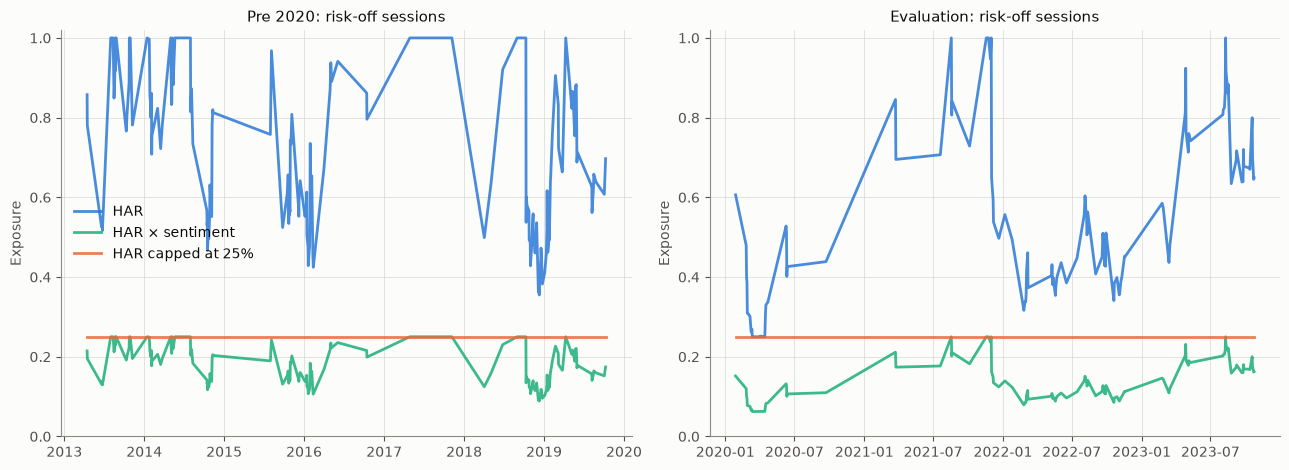

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for axis, era in zip(axes, INPUTS, strict=True):
    risk_off = exposures[era]["product"]["modifier_exposure"].eq(0.25)
    for arm, label, colour in (
        ("har_base", "HAR", CATEGORICAL[0]),
        ("product", "HAR × sentiment", CATEGORICAL[2]),
        ("absolute_cap", "HAR capped at 25%", CATEGORICAL[1]),
    ):
        use = exposures[era][arm].loc[risk_off]
        axis.plot(use["session_date"], use["exposure"], label=label, color=colour, alpha=0.85)
    axis.set_ylim(0.0, 1.02)
    axis.set_title(f"{era.replace('_', ' ').title()}: risk-off sessions")
    axis.set_ylabel("Exposure")
axes[0].legend(loc="best")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "risk_off_exposure_comparison.png", dpi=170, bbox_inches="tight")
plt.show()

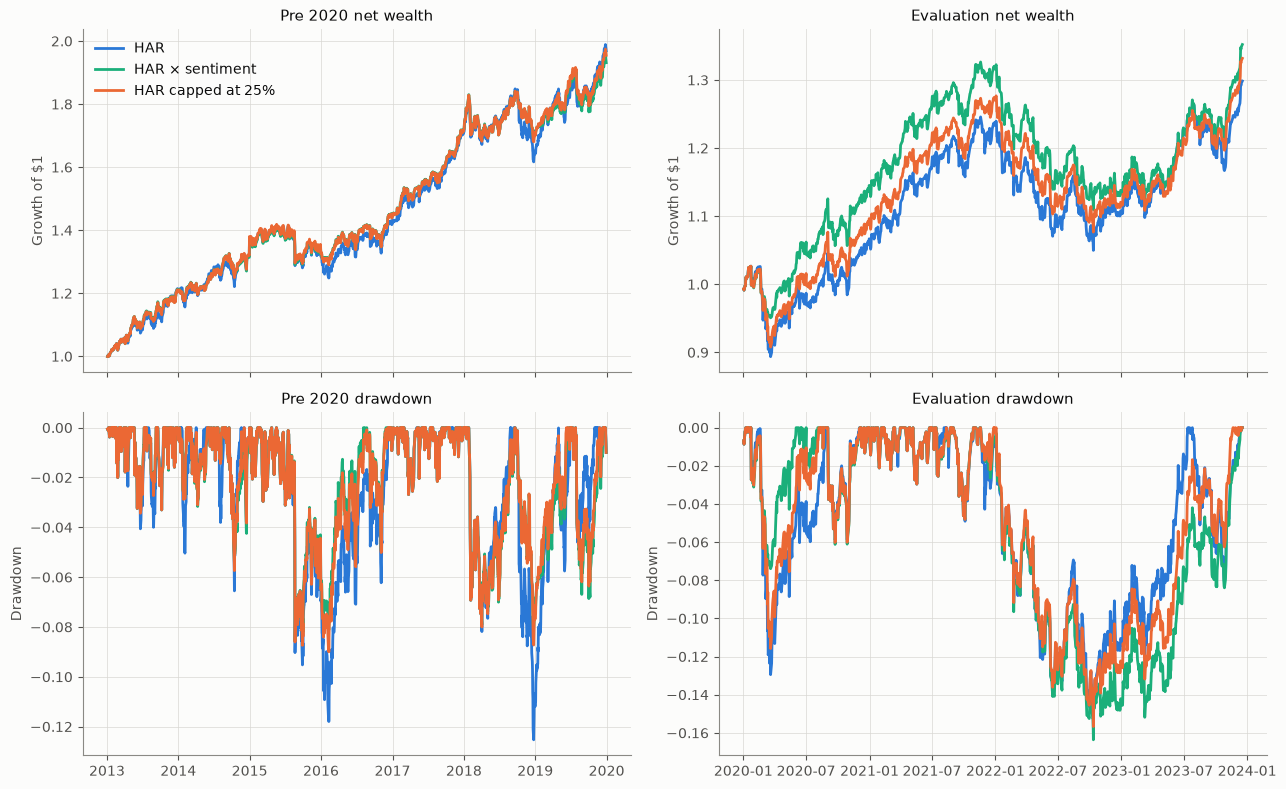

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex="col")
for column, era in enumerate(INPUTS):
    for arm, label, colour in (
        ("har_base", "HAR", CATEGORICAL[0]),
        ("product", "HAR × sentiment", CATEGORICAL[2]),
        ("absolute_cap", "HAR capped at 25%", CATEGORICAL[1]),
    ):
        daily = daily_paths[era][arm]
        equity = (1.0 + daily["net_return"]).cumprod()
        drawdown = equity / np.maximum.accumulate(np.r_[1.0, equity])[-len(equity):] - 1.0
        axes[0, column].plot(daily["session_date"], equity, label=label, color=colour)
        axes[1, column].plot(daily["session_date"], drawdown, label=label, color=colour)
    axes[0, column].set_title(f"{era.replace('_', ' ').title()} net wealth")
    axes[1, column].set_title(f"{era.replace('_', ' ').title()} drawdown")
    axes[0, column].set_ylabel("Growth of $1")
    axes[1, column].set_ylabel("Drawdown")
axes[0, 0].legend(loc="best")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "equity_and_drawdown_by_era.png", dpi=170, bbox_inches="tight")
plt.show()

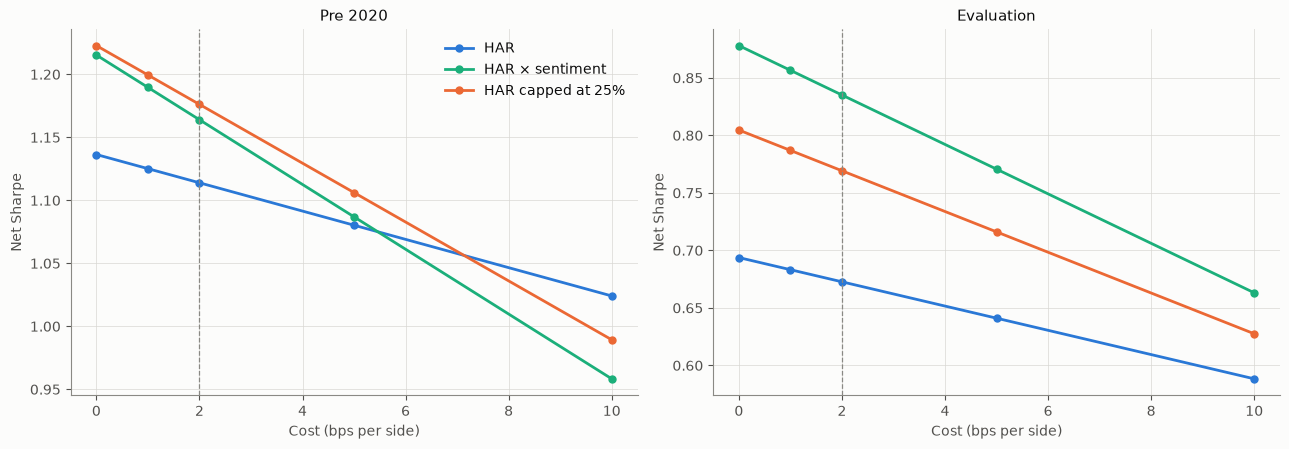

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for axis, era in zip(axes, INPUTS, strict=True):
    for arm, label, colour in (
        ("har_base", "HAR", CATEGORICAL[0]),
        ("product", "HAR × sentiment", CATEGORICAL[2]),
        ("absolute_cap", "HAR capped at 25%", CATEGORICAL[1]),
    ):
        line = cost_curve.loc[cost_curve["era"].eq(era) & cost_curve["arm"].eq(arm)]
        axis.plot(
            line["cost_bps_per_side"],
            line["sharpe_net"],
            marker="o",
            label=label,
            color=colour,
        )
    axis.axvline(COST_BPS, color=INK["muted"], linestyle="--", linewidth=0.9)
    axis.set_title(era.replace("_", " ").title())
    axis.set_xlabel("Cost (bps per side)")
    axis.set_ylabel("Net Sharpe")
axes[0].legend(loc="best")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "cost_curve_by_era.png", dpi=170, bbox_inches="tight")
plt.show()

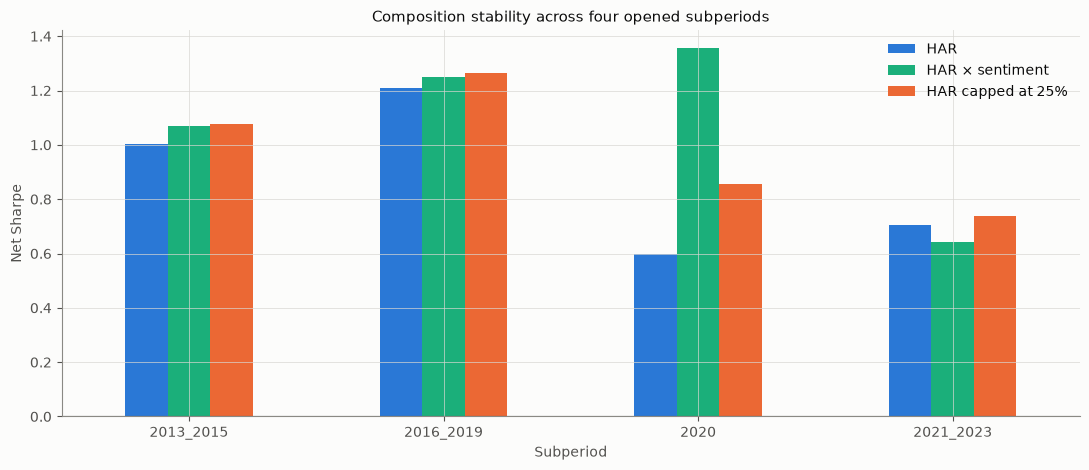

In [11]:
plot = temporal.pivot(index="period", columns="arm", values="sharpe_net").reindex(
    ["2013_2015", "2016_2019", "2020", "2021_2023"]
)
plot = plot[["har_base", "product", "absolute_cap"]].rename(
    columns={"har_base": "HAR", "product": "HAR × sentiment", "absolute_cap": "HAR capped at 25%"}
)
ax = plot.plot(
    kind="bar",
    figsize=(11, 4.8),
    color=[CATEGORICAL[0], CATEGORICAL[2], CATEGORICAL[1]],
)
ax.axhline(0.0, color=INK["reference"], linewidth=0.8)
ax.set_xlabel("Subperiod")
ax.set_ylabel("Net Sharpe")
ax.set_title("Composition stability across four opened subperiods")
ax.legend(loc="best")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "subperiod_sharpe.png", dpi=170, bbox_inches="tight")
plt.show()

## Persist aggregate outputs and decision

In [12]:
input_audit.to_csv(OUTPUT_DIR / "input_audit.csv", index=False)
results.to_csv(OUTPUT_DIR / "results.csv", index=False)
inference.to_csv(OUTPUT_DIR / "paired_inference.csv", index=False)
cost_curve.to_csv(OUTPUT_DIR / "cost_curve.csv", index=False)
temporal.to_csv(OUTPUT_DIR / "temporal_results.csv", index=False)
exposure_summary.to_csv(OUTPUT_DIR / "exposure_summary.csv", index=False)
operator_table.to_csv(OUTPUT_DIR / "operator_checks.csv", index=False)
post_result_stability.to_csv(OUTPUT_DIR / "post_result_stability.csv", index=False)
pd.DataFrame([gates]).to_csv(OUTPUT_DIR / "gates.csv", index=False)
for era, arms in daily_paths.items():
    for arm, daily in arms.items():
        daily.to_parquet(OUTPUT_DIR / f"{era}_{arm}_daily.parquet", index=False)

try:
    git_commit = subprocess.run(
        ["git", "rev-parse", "HEAD"],
        cwd=REPO_ROOT,
        check=True,
        capture_output=True,
        text=True,
    ).stdout.strip()
except (OSError, subprocess.CalledProcessError):
    git_commit = None

manifest = {
    "notebook": "27_fnspid_har_sentiment_composition",
    "built_for": "single unchanged absolute-cap versus multiplier composition audit across both opened eras",
    "analysis_status": "iterative_post_result_operator_selection_2026-08-05",
    "git_commit_at_execution": git_commit,
    "design": {
        "base": "unchanged sentiment-free HAR 10% volatility target",
        "sentiment_state": "unchanged 1.5 entry / 0.5 exit hysteresis with risk-off value 0.25",
        "product": "base exposure multiplied by sentiment state",
        "absolute_cap": "minimum of base exposure and sentiment state",
        "cost_bps_per_side": COST_BPS,
        "cost_grid": list(COST_GRID),
        "bootstrap": {
            "kind": "paired circular block",
            "block_length": BLOCK_LENGTH,
            "replications": REPLICATIONS,
            "seed": SEED,
        },
        "multiplicity": "BH separately over four cap-comparator tests for net return and four for downside squared",
    },
    "input_audit": json.loads(input_audit.to_json(orient="records", date_format="iso")),
    "results": json.loads(results.to_json(orient="records")),
    "paired_inference": json.loads(inference.to_json(orient="records")),
    "operator_checks": json.loads(operator_table.to_json(orient="records")),
    "post_result_stability": json.loads(post_result_stability.to_json(orient="records")),
    "gates": gates,
    "limitations": [
        "both return eras were opened before this operator comparison",
        "the alternative operator was proposed after the product results were known",
        "the test changes portfolio composition only and does not create independent sentiment evidence",
        "SPY adjusted-open returns omit dividends and cash earns zero",
        "future validation must freeze one chosen operator rather than compare both again",
    ],
}
(OUTPUT_DIR / "manifest.json").write_text(json.dumps(manifest, indent=2, allow_nan=True) + "\n")

lines = []
for era in INPUTS:
    base = result_index.loc[(era, "har_base")]
    product = result_index.loc[(era, "product")]
    cap = result_index.loc[(era, "absolute_cap")]
    cap_product = inference_index.loc[(era, "product", "net_return")]
    lines.append(
        f"- {era.replace('_', ' ').title()}: HAR/product/cap net Sharpes "
        f"**{base['sharpe_net']:.3f}/{product['sharpe_net']:.3f}/{cap['sharpe_net']:.3f}**; "
        f"cap minus product **{cap_product['mean'] * 10_000:.3f} bps/day** "
        f"[{cap_product['ci_low'] * 10_000:.3f}, {cap_product['ci_high'] * 10_000:.3f}]."
    )
operator_verdict = "passes" if operator_selection_gate else "does not pass"
alpha_verdict = "passes" if gates["alpha_gate_both_eras"] else "does not pass"
risk_verdict = "passes" if gates["useful_risk_gate_both_eras"] else "does not pass"
cap_sharpe_wins = int(post_result_stability["cap_sharpe_above_base"].sum())
cap_product_sharpe_wins = int(post_result_stability["cap_sharpe_above_product"].sum())
display(
    Markdown(
        f"""### Decision

The absolute-cap operator **{operator_verdict}** the frozen operator-selection
gate. It **{alpha_verdict}** the cross-era alpha gate and **{risk_verdict}** the
cross-era useful-risk gate.

{chr(10).join(lines)}

The labelled post-result stability diagnostic shows the cap above HAR Sharpe in
**{cap_sharpe_wins}/4** subperiods and above the product in **{cap_product_sharpe_wins}/4**;
the product's full-evaluation advantage is concentrated in 2020. This does not
override the failed frozen gate.

The result chooses between two interpretations of the same already-opened
sentiment state. Even a passing operator gate would select a cleaner candidate
for future data; it would not establish current-sample alpha.
"""
    )
)

### Decision

The absolute-cap operator **does not pass** the frozen operator-selection
gate. It **does not pass** the cross-era alpha gate and **does not pass** the
cross-era useful-risk gate.

- Pre 2020: HAR/product/cap net Sharpes **1.114/1.164/1.176**; cap minus product **0.071 bps/day** [-0.071, 0.214].
- Evaluation: HAR/product/cap net Sharpes **0.673/0.835/0.769**; cap minus product **-0.136 bps/day** [-0.964, 0.483].

The labelled post-result stability diagnostic shows the cap above HAR Sharpe in
**4/4** subperiods and above the product in **3/4**;
the product's full-evaluation advantage is concentrated in 2020. This does not
override the failed frozen gate.

The result chooses between two interpretations of the same already-opened
sentiment state. Even a passing operator gate would select a cleaner candidate
for future data; it would not establish current-sample alpha.
